In [2]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, tan, einsum
import torch
import warnings
warnings.filterwarnings("ignore")
#from refractiveindex import RefractiveIndexMaterial
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator, graphene_conductivity

In [3]:
hbar = 6.67*1e-16 # hbar in eV*seconds
tau = 6.4*1e-13 # scattering time in seconds
c = 3*10**17; # speed of light in nanometers per second
alpha = 1/137; # fine structure constant

In [4]:
M = 1000
epsilon = 12
x_1 = 1e-3
x_2 = 0.09
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = (1/x)/(j_ly*(j_lx**2+y_lx**2))
mat = np.array([[y_lx, j_lx], [-j_lx , y_lx]])
vec = np.array([j_lx*yjl_prime-xjl_prime*j_ly, j_ly*xyl_prime-y_lx*yjl_prime])

In [5]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]
small_sphere_dispersion = -(2*l+1)/x

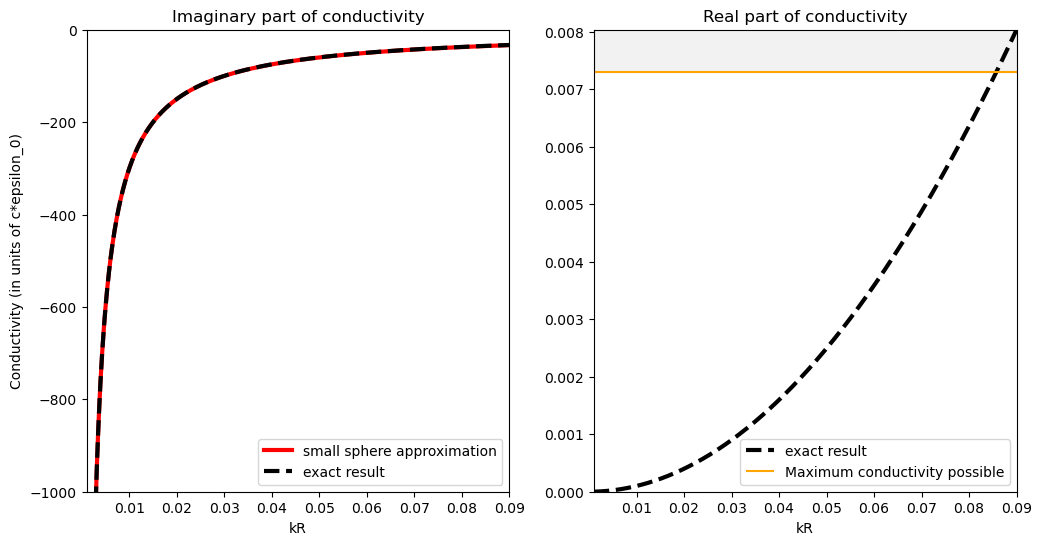

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, small_sphere_dispersion, label="small sphere approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax1.set_ylim(-1000, 0)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.hlines([alpha], x_1, x_2, label="Maximum conductivity possible", color="orange")
ax2.fill([x_1, x_1, x_2, x_2], [alpha, 2*alpha, 2*alpha, alpha], color="grey", alpha=0.1)
ax2.set_ylim(sigma_real.min(), sigma_real.max())
ax2.set_ylim(0, )
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.legend();
#plt.savefig("./cleo_2026/te_conductivity_smallx.pdf")

In [8]:
M = 1000
epsilon = 12
x_1 = 0.87
x_2 = 0.97
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = (1/x)/(j_ly*(j_lx**2+y_lx**2))
mat = np.array([[y_lx, j_lx], [-j_lx , y_lx]])
vec = np.array([j_lx*yjl_prime-xjl_prime*j_ly, j_ly*xyl_prime-y_lx*yjl_prime])

In [9]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]
small_sphere_dispersion = -(2*l+1)/x

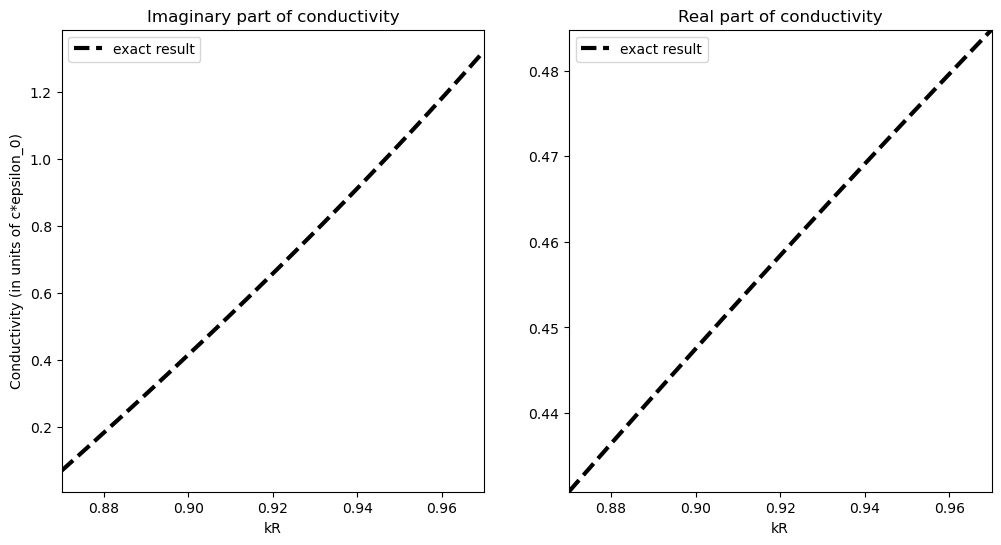

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
#ax1.set_ylim(0, 1.5)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();
ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_ylim(sigma_real.min(), sigma_real.max())
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.legend();
#plt.savefig("./cleo_2026/te_conductivity_largex.pdf");

In [12]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;
hbar_omega = hbar*(sigma_imaginary/sigma_real)*(1/tau)

In [13]:
s_sqrds = abs(h_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])*x))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  2.2035027369144745e-30


In [14]:
idxs = [500]
M = int(1e5)
omega_range = linspace(2, 4, M)*1e12 # frequency range we examine (in Hertz)
s_sqrds = zeros((len(idxs), M))

for (sq_idx, idx) in enumerate(idxs):
    x_range = omega_range * a[idx]/c # keep radius fixed
    sigma_range = graphene_conductivity(E_F[idx], hbar*omega_range, hbar/tau, False)
    g_omega_range = sigma_range*1j*x_range
    s_sqrds[sq_idx, :] = abs(h_r_cpa(l, x_range, epsilon, g_omega_range))**2

In [15]:
print("Minimum |s|^2 for each index: ", s_sqrds.min((1)))

Minimum |s|^2 for each index:  [3.1157244e-09]


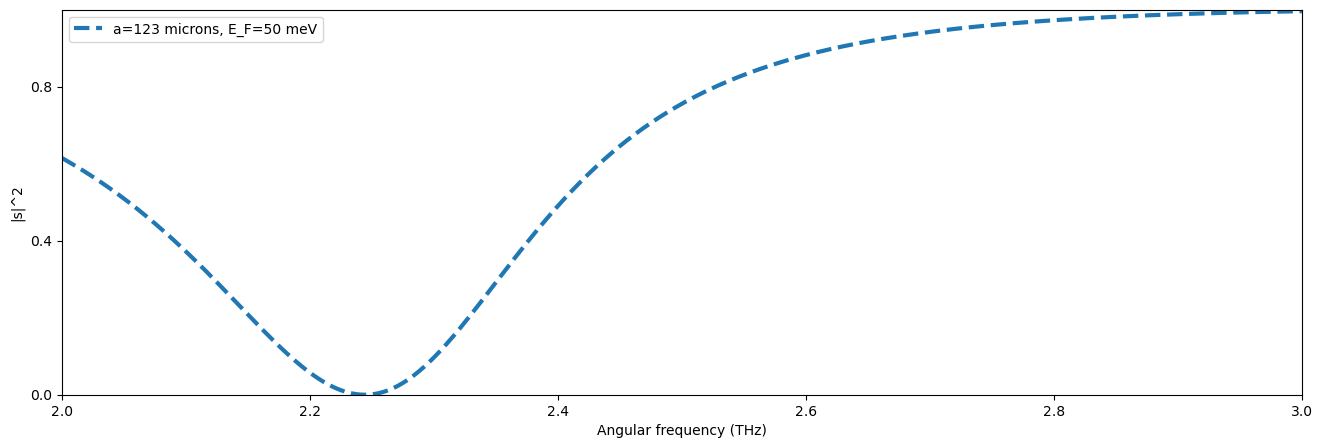

In [16]:
fig, ax = plt.subplots(figsize=(16, 5))
for (sq_idx, idx) in enumerate(idxs):
    ax.plot(omega_range/1e12, s_sqrds[sq_idx], linestyle="dashed", linewidth=3, label=f"a={round(a[idx]/1e3)} microns, E_F={round(E_F[idx]*1e3)} meV")
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.4, 0.8])
ax.set_xlim(2, 3);
ax.set_xlabel("Angular frequency (THz)");
ax.set_ylabel("|s|^2");
ax.legend();
#plt.savefig("./cleo_2026/graphene_te_bandwidth.pdf")